# TDA Mapper on G25 Genetic Coordinates

**Topological Data Analysis of human genetic variation.**  
Dataset: Eurogenes Global 25 (G25) — 10,927 individual samples, 1,003 populations, 25 principal components.

### Pipeline
1. Load and parse G25 coordinate data  
2. Aggregate to population means; assign macro-regional labels via unsupervised K-means  
3. Build a Mapper graph using 2D UMAP as filter function + DBSCAN clustering  
4. Render static poster and interactive HTML visualization  

### Stack
`pandas` · `numpy` · `scikit-learn` · `umap-learn` · `kmapper` · `networkx` · `scipy` · `matplotlib` · `Pillow` · `plotly`

In [1]:
import sys
!{sys.executable} -m pip install umap-learn kmapper plotly Pillow --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Data Loading

Raw file format: `PopulationName:SampleID, PC1, ..., PC25`  
Each row is one individual. Index is split into `population` and `sample_id`.

In [2]:
# Load & parse G25 coordinate data
import pandas as pd
import numpy as np

df = pd.read_csv("g25_coordinates.txt", index_col=0)

df.index.name = "raw_id"
df = df.reset_index()
df[["population", "sample_id"]] = df["raw_id"].str.split(":", n=1, expand=True)
df = df.drop(columns="raw_id")

pc_cols = [c for c in df.columns if c.startswith("PC")]
print(f"Samples: {len(df):,}  |  Populations: {df['population'].nunique():,}  |  PCs: {len(pc_cols)}")

print("\nMissing values per PC:")
print(df[pc_cols].isnull().sum().sum(), "total NaN")

print("\nTop-10 populations by sample count:")
print(df["population"].value_counts().head(10).to_string())

X = df[pc_cols].values.astype(np.float64)
print(f"\nFeature matrix shape: {X.shape}")
print(f"PC1 range: [{X[:, 0].min():.4f}, {X[:, 0].max():.4f}]")

Samples: 10,927  |  Populations: 1,003  |  PCs: 25

Missing values per PC:
0 total NaN

Top-10 populations by sample count:
population
Dutch                                  166
Lebanese_Maronite_Christian_Zgharta    135
German                                 101
Swedish                                101
Greek_Crete                            100
Manchu_Liaoning                         96
Punjabi_Lahore                          96
Irish                                   85
Danish                                  81
Lebanese_Orthodox_Christian_Koura       81

Feature matrix shape: (10927, 25)
PC1 range: [-0.6545, 0.1457]


## 2. Region Assignment via K-means Clustering

Instead of manually labeling populations by region, we derive labels directly from the data.  
K-means is applied to the full 25-dimensional PC space on **population means** (1,003 points).

**Why unscaled PCs?**  
PC variance hierarchy is meaningful — PC1 captures the largest axis of global genetic diversity.  
Scaling would artificially inflate the influence of noisy later components.

**Why K=9?**  
Silhouette score has two local maxima: K=3 (trivial Africa/West Eurasia/East Asia split)  
and K=7–9 (genetically interpretable finer structure). K=9 was selected because it separates  
Europe from Middle East & Caucasus — a distinction that is both statistically stable and  
scientifically meaningful.

Population matrix: (1003, 25)
K= 2  inertia=64.7  silhouette=0.4452
K= 3  inertia=33.9  silhouette=0.5448
K= 4  inertia=24.5  silhouette=0.4948
K= 5  inertia=20.0  silhouette=0.5193
K= 6  inertia=17.3  silhouette=0.5233
K= 7  inertia=14.7  silhouette=0.5267
K= 8  inertia=12.5  silhouette=0.4482
K= 9  inertia=10.7  silhouette=0.4405
K=10  inertia=9.6  silhouette=0.4223
K=11  inertia=8.7  silhouette=0.4302
K=12  inertia=8.0  silhouette=0.4306
K=13  inertia=7.4  silhouette=0.4159
K=14  inertia=6.9  silhouette=0.4110
K=15  inertia=6.3  silhouette=0.4110


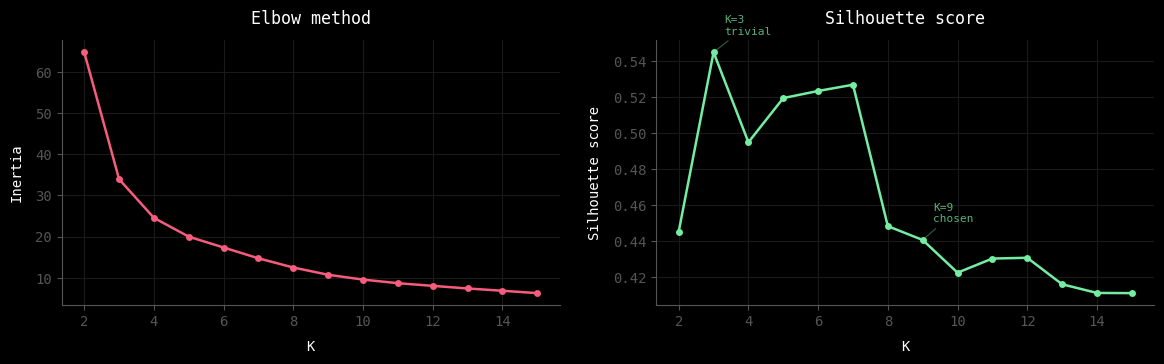


Peak silhouette at K=3


In [ ]:
# Population means + K-means K selection (elbow + silhouette)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Aggregate to population-level means
pop_df = (
    df.groupby("population")[pc_cols]
    .mean()
    .reset_index()
)
X_pop = pop_df[pc_cols].values.astype(np.float64)
print(f"Population matrix: {X_pop.shape}")

# Sweep K = 2..15
K_range     = range(2, 16)
inertias    = []
silhouettes = []

for k in K_range:
    km_sweep = KMeans(n_clusters=k, random_state=42, n_init=20)
    lab = km_sweep.fit_predict(X_pop)
    inertias.append(km_sweep.inertia_)
    silhouettes.append(silhouette_score(X_pop, lab))
    print(f"K={k:2d}  inertia={km_sweep.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

# ── Dark theme ────────────────────────────────────────────────────────────
BG      = "#000000"
GRID    = "#1a1a1a"
TEXT    = "#ffffff"
MUTED   = "#555555"
COLOR_1 = "#F55C7D"   # elbow
COLOR_2 = "#74EDA3"   # silhouette

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    MUTED,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "grid.color":        GRID,
    "text.color":        TEXT,
    "font.family":       "monospace",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(BG)

ks = list(K_range)

# Elbow
ax1.plot(ks, inertias, "o-", color=COLOR_1, linewidth=1.8,
         markersize=5, markerfacecolor=COLOR_1, markeredgewidth=0)
ax1.set_xlabel("K", labelpad=8)
ax1.set_ylabel("Inertia", labelpad=8)
ax1.set_title("Elbow method", pad=12)
ax1.grid(True, alpha=1)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color(MUTED)

# Silhouette
ax2.plot(ks, silhouettes, "o-", color=COLOR_2, linewidth=1.8,
         markersize=5, markerfacecolor=COLOR_2, markeredgewidth=0)
ax2.set_xlabel("K", labelpad=8)
ax2.set_ylabel("Silhouette score", labelpad=8)
ax2.set_title("Silhouette score", pad=12)
ax2.grid(True, alpha=1)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color(MUTED)

# Annotate K=3 and K=9 on silhouette plot
for k_mark, label, yoff in [(3, "K=3\ntrivial", 0.01), (9, "K=9\nchosen", 0.01)]:
    idx = ks.index(k_mark)
    ax2.annotate(
        label,
        xy=(k_mark, silhouettes[idx]),
        xytext=(k_mark + 0.3, silhouettes[idx] + yoff),
        fontsize=8, color=COLOR_2, alpha=0.75,
        arrowprops=dict(arrowstyle="-", color=COLOR_2, alpha=0.4, lw=0.8),
    )

plt.tight_layout(pad=2)
plt.savefig("k_selection.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

best_k = ks[silhouettes.index(max(silhouettes))]
print(f"\nPeak silhouette at K={best_k}")

In [30]:
# Finalize K=9: fit, assign region names, merge back to sample level
BEST_K   = 9
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
pop_df["cluster"] = km_final.fit_predict(X_pop)

# Region names derived from cluster composition inspection
# K=9 chosen: second silhouette peak; separates Europe from Middle East & Caucasus
CLUSTER_NAMES = {
    0: "South Asia",
    1: "Sub-Saharan Africa (West & Central)",
    2: "East & Southeast Asia",
    3: "Europe",
    4: "Americas",
    5: "East Africa & Horn",
    6: "Middle East & Caucasus",
    7: "Oceania",
    8: "Inner Eurasia",
}

pop_df["region"] = pop_df["cluster"].map(CLUSTER_NAMES)

print("Final region distribution (populations):")
print(pop_df["region"].value_counts().to_string())
print(f"\nTotal populations: {len(pop_df)}  |  Unmapped: {pop_df['region'].isna().sum()}")

# Transfer region labels back to sample level
df = df.drop(columns=["region", "cluster"], errors="ignore")
df = df.merge(pop_df[["population", "region", "cluster"]], on="population", how="left")
print("\nSample-level region distribution:")
print(df["region"].value_counts().to_string())

Final region distribution (populations):
region
Middle East & Caucasus                 275
Europe                                 203
South Asia                             196
East & Southeast Asia                  132
Inner Eurasia                           70
Sub-Saharan Africa (West & Central)     56
East Africa & Horn                      42
Americas                                22
Oceania                                  7

Total populations: 1003  |  Unmapped: 0

Sample-level region distribution:
region
Middle East & Caucasus                 3002
Europe                                 2950
East & Southeast Asia                  1627
South Asia                             1407
Inner Eurasia                           863
Sub-Saharan Africa (West & Central)     563
East Africa & Horn                      407
Americas                                 76
Oceania                                  32


## 3. Mapper Graph

### Algorithm overview
The Mapper algorithm captures the **shape** of high-dimensional data as a graph:

1. **Filter function** — project data to a lower-dimensional space (here: 2D UMAP)
2. **Cover** — partition the filter range into overlapping intervals (`n_cubes`, `perc_overlap`)
3. **Clustering** — apply DBSCAN within each interval; each cluster becomes a **node**
4. **Edges** — connect nodes that share points from overlapping intervals

### Parameter choices
| Parameter | Value | Rationale |
|---|---|---|
| Filter | 2D UMAP | Richer topology than 1D; allows non-linear arrangement of cover bins |
| n_cubes | 15 | Explored 10–15; 15 gave best node/edge ratio (~1.0) |
| perc_overlap | 0.5 | Standard value; 0.6 over-connected the graph |
| DBSCAN eps | 0.05 | Calibrated from pairwise distance distribution (p10 ≈ 0.095) |

**Result:** 194 nodes · 358 edges · mean node purity **0.97**

In [5]:
# 2D UMAP filter function
import umap
import kmapper as km
from sklearn.cluster import DBSCAN

reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)
lens_2d = reducer_2d.fit_transform(X_pop)
print(f"Lens 2D shape: {lens_2d.shape}")
print(f"Range X: [{lens_2d[:, 0].min():.3f}, {lens_2d[:, 0].max():.3f}]")
print(f"Range Y: [{lens_2d[:, 1].min():.3f}, {lens_2d[:, 1].max():.3f}]")

mapper = km.KeplerMapper(verbose=0)

c:\Users\GSTQ\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\GSTQ\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Lens 2D shape: (1003, 2)
Range X: [-6.140, 16.122]
Range Y: [-4.726, 16.633]


In [6]:
# Build final Mapper graph + node/edge metadata
FINAL_CUBES   = 15
FINAL_OVERLAP = 0.5
FINAL_EPS     = 0.05

graph = mapper.map(
    lens_2d,
    X_pop,
    cover=km.Cover(n_cubes=FINAL_CUBES, perc_overlap=FINAL_OVERLAP),
    clusterer=DBSCAN(metric="euclidean", min_samples=2, eps=FINAL_EPS)
)

# Build node-level dataframe
rows = []
for node_id, member_indices in graph["nodes"].items():
    member_pops     = pop_df.iloc[member_indices]
    dominant_region = member_pops["region"].value_counts().idxmax()
    region_purity   = member_pops["region"].value_counts().iloc[0] / len(member_indices)
    rows.append({
        "node_id":         node_id,
        "size":            len(member_indices),
        "dominant_region": dominant_region,
        "region_purity":   region_purity,
        "mean_pc1":        member_pops[pc_cols[0]].mean(),
        "mean_pc2":        member_pops[pc_cols[1]].mean(),
        "umap_x":          lens_2d[member_indices, 0].mean(),
        "umap_y":          lens_2d[member_indices, 1].mean(),
        "populations":     ", ".join(member_pops["population"].tolist()),
    })

nodes_df = pd.DataFrame(rows)

edges = []
for src, targets in graph["links"].items():
    for tgt in targets:
        edges.append({"source": src, "target": tgt})
edges_df = pd.DataFrame(edges)

print(f"Nodes: {len(nodes_df)}")
print(f"Edges: {len(edges_df)}")
print(f"\nRegion distribution across nodes:")
print(nodes_df["dominant_region"].value_counts().to_string())
print(f"\nMean node purity: {nodes_df['region_purity'].mean():.3f}")

Nodes: 194
Edges: 358

Region distribution across nodes:
dominant_region
Middle East & Caucasus                 45
Inner Eurasia                          36
South Asia                             30
East & Southeast Asia                  25
Sub-Saharan Africa (West & Central)    20
Europe                                 19
East Africa & Horn                     12
Americas                                5
Oceania                                 2

Mean node purity: 0.970


## 4. Visualization

Three outputs:
1. **PCA scatter** — baseline comparison showing what standard dimensionality reduction reveals
2. **Static poster** — gaussian glow render for Behance hero image  
3. **Interactive HTML** — Plotly graph with hover, zoom, and pan (hosted separately)

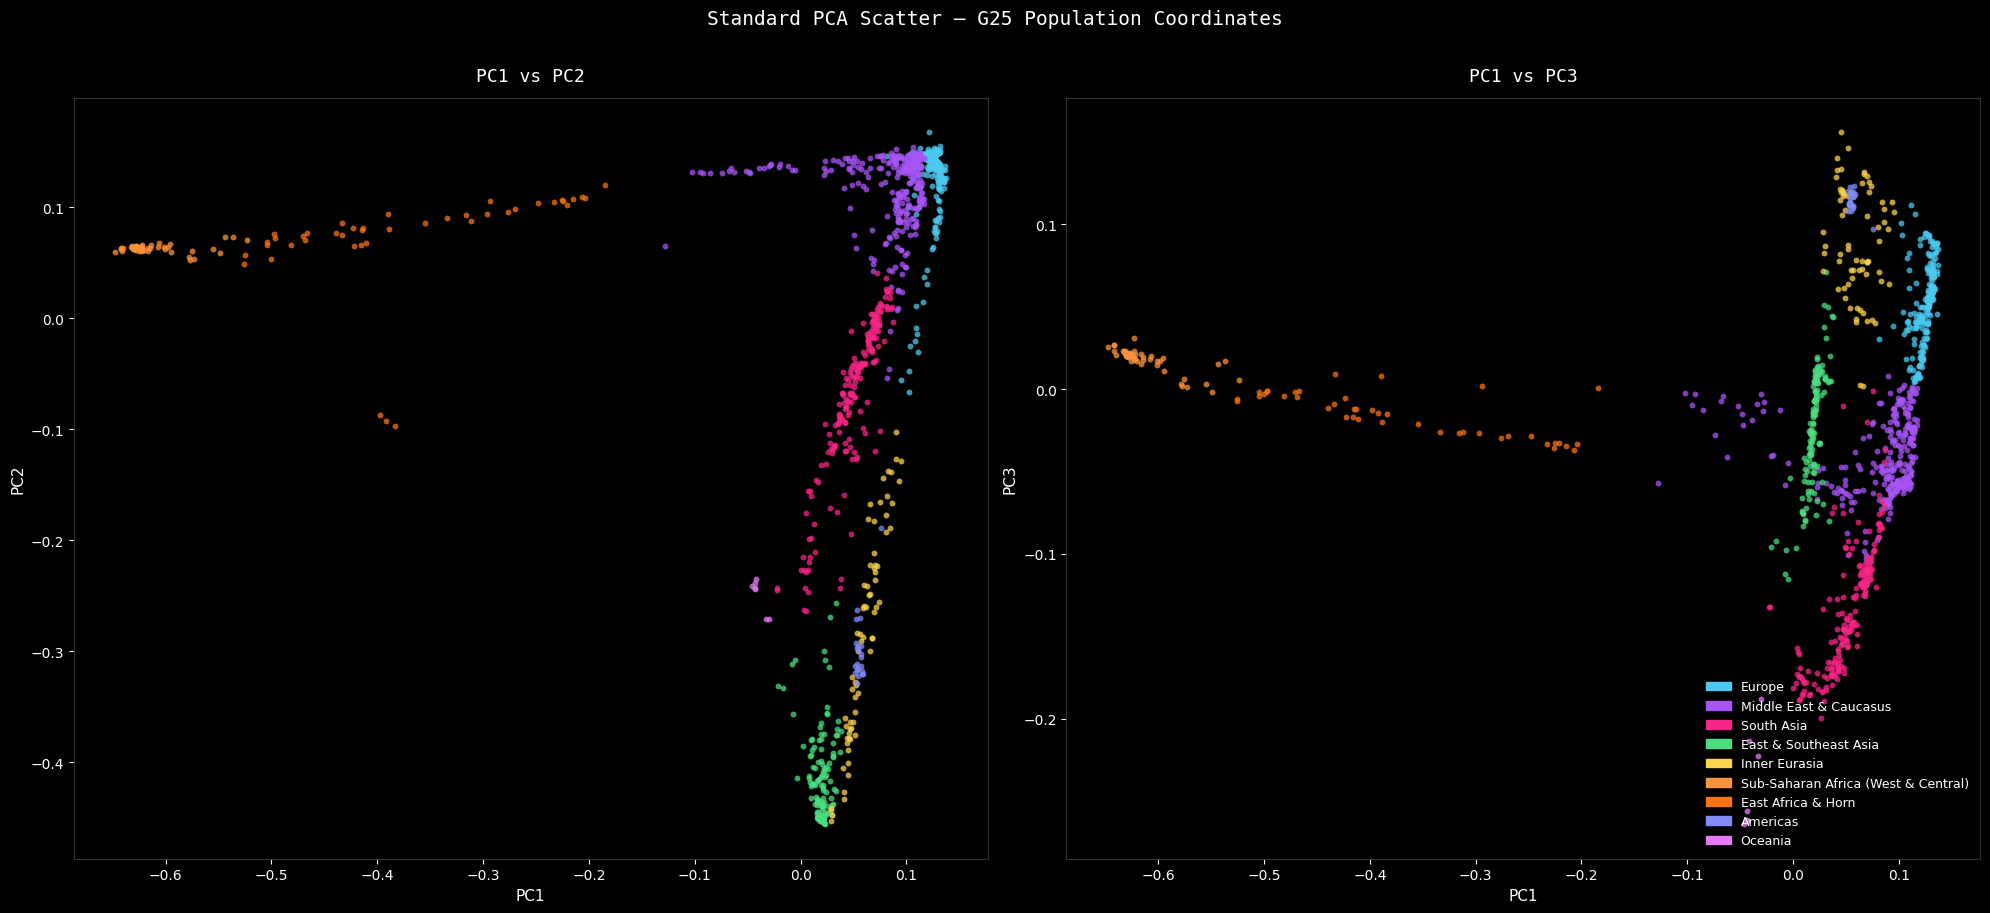

Saved: g25_pca_scatter.png


In [7]:
# Baseline comparison: standard PCA scatter (what everyone does)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REGION_COLORS = {
    "Europe":                              "#4CC9F0",
    "Middle East & Caucasus":              "#A855F7",
    "South Asia":                          "#F72585",
    "East & Southeast Asia":               "#4ADE80",
    "Inner Eurasia":                       "#FCD34D",
    "Sub-Saharan Africa (West & Central)": "#FB923C",
    "East Africa & Horn":                  "#F97316",
    "Americas":                            "#818CF8",
    "Oceania":                             "#E879F9",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor("#000000")

for ax, (xi, yi), title in zip(axes, [(0, 1), (0, 2)], ["PC1 vs PC2", "PC1 vs PC3"]):
    ax.set_facecolor("#000000")
    for region, color in REGION_COLORS.items():
        mask = pop_df["region"] == region
        ax.scatter(
            pop_df.loc[mask, pc_cols[xi]],
            pop_df.loc[mask, pc_cols[yi]],
            c=color, s=18, alpha=0.75, linewidths=0,
        )
    ax.set_xlabel(f"PC{xi+1}", color="white", fontsize=11)
    ax.set_ylabel(f"PC{yi+1}", color="white", fontsize=11)
    ax.set_title(title, color="white", fontsize=13, fontfamily="monospace", pad=12)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
axes[1].legend(handles=patches, framealpha=0, labelcolor="white",
               fontsize=9, loc="lower right")
fig.suptitle("Standard PCA Scatter — G25 Population Coordinates",
             color="white", fontsize=14, fontfamily="monospace", y=1.01)
plt.tight_layout()
plt.savefig("g25_pca_scatter.png", dpi=200, bbox_inches="tight", facecolor="#000000")
plt.show()
print("Saved: g25_pca_scatter.png")

In [27]:
import json
import plotly.graph_objects as go

REGION_COLORS = {
    "Europe":                              "#4CC9F0",
    "Middle East & Caucasus":              "#A855F7",
    "South Asia":                          "#F72585",
    "East & Southeast Asia":               "#4ADE80",
    "Inner Eurasia":                       "#FCD34D",
    "Sub-Saharan Africa (West & Central)": "#FB923C",
    "East Africa & Horn":                  "#F97316",
    "Americas":                            "#818CF8",
    "Oceania":                             "#E879F9",
}

node_list  = list(G.nodes)
sizes_raw  = np.array([G.nodes[n]["size"] for n in node_list], dtype=float)
sizes_norm = (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min())
brightness = 0.25 + 0.75 * (sizes_norm ** 0.65)
node_idx   = {n: i for i, n in enumerate(node_list)}

all_traces = []

# Edges
for u, v in G.edges():
    i, j    = node_idx[u], node_idx[v]
    b_avg   = (brightness[i] + brightness[j]) / 2
    opacity = 0.08 + b_avg * 0.22
    c1 = np.array([int(REGION_COLORS[G.nodes[u]["region"]][k:k+2], 16) for k in (1, 3, 5)], dtype=float) / 255
    c2 = np.array([int(REGION_COLORS[G.nodes[v]["region"]][k:k+2], 16) for k in (1, 3, 5)], dtype=float) / 255
    rgb   = np.clip((c1 + c2) / 2 * 0.45 + 0.35, 0, 1) * 255
    color = f"rgba({int(rgb[0])},{int(rgb[1])},{int(rgb[2])},{opacity:.2f})"
    all_traces.append(go.Scatter(
        x=[pos[u][0], pos[v][0], None], y=[pos[u][1], pos[v][1], None],
        mode="lines", line=dict(width=0.5 + b_avg * 1.2, color=color),
        hoverinfo="none", showlegend=False,
    ))

# 10 glow layers
n_layers   = 10
size_mults = np.geomspace(3.5, 0.15, n_layers)
opacities  = np.geomspace(0.012, 0.18, n_layers)

for layer_i, (size_mult, layer_op) in enumerate(zip(size_mults, opacities)):
    is_core = (layer_i == n_layers - 1)
    for region, color in REGION_COLORS.items():
        mask = [G.nodes[n]["region"] == region for n in node_list]
        idx  = [i for i, m in enumerate(mask) if m]
        if not idx:
            continue
        all_traces.append(go.Scatter(
            x=[pos[node_list[i]][0] for i in idx],
            y=[pos[node_list[i]][1] for i in idx],
            mode="markers",
            name=region if is_core else None,
            legendgroup=region, showlegend=is_core,
            marker=dict(size=[(8 + brightness[i] * 22) * size_mult for i in idx],
                        color=color, opacity=layer_op, line=dict(width=0)),
            hoverinfo="none",
        ))

# White hard core
for region, color in REGION_COLORS.items():
    mask = [G.nodes[n]["region"] == region for n in node_list]
    idx  = [i for i, m in enumerate(mask) if m]
    if idx:
        all_traces.append(go.Scatter(
            x=[pos[node_list[i]][0] for i in idx],
            y=[pos[node_list[i]][1] for i in idx],
            mode="markers", name=None, legendgroup=region, showlegend=False,
            marker=dict(size=[3 + brightness[i] * 7 for i in idx],
                        color="white", opacity=0.75, line=dict(width=0)),
            hoverinfo="none",
        ))

fig = go.Figure(data=all_traces)
fig.update_layout(
    title=dict(
        text="The Shape of Human Genetic Variation<br><sup>Mapper Graph · G25 Coordinates · 1,003 Populations · 25 Dimensions</sup>",
        font=dict(color="white", family="monospace", size=15),
        x=0.5, xanchor="center", y=0.97,
    ),
    paper_bgcolor="#000000", plot_bgcolor="#000000", showlegend=True,
    legend=dict(font=dict(color="white", family="monospace", size=11),
                bgcolor="rgba(0,0,0,0.6)", bordercolor="rgba(255,255,255,0.08)",
                borderwidth=1, itemsizing="constant", x=0.01, y=0.01),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               scaleanchor="y", scaleratio=1),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    margin=dict(l=0, r=0, t=60, b=0), hovermode="closest",
)

plot_div = fig.to_html(include_plotlyjs="cdn", full_html=False,
                       config={"scrollZoom": True, "displayModeBar": False})

# ── Precompute JSON outside f-string to avoid escaping issues ─────────────
node_data_json = json.dumps({
    str(i): {
        "region": G.nodes[n]["region"],
        "pops":   sorted(pop_df.iloc[graph["nodes"][n]]["population"].tolist())
    }
    for i, n in enumerate(node_list)
})
pos_data_json  = json.dumps({n: [float(pos[n][0]), float(pos[n][1])] for n in node_list})
node_list_json = json.dumps(node_list)

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Human Genetic Variation — Mapper Graph</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/html2canvas/1.4.1/html2canvas.min.js"></script>
<style>
  * {{ margin: 0; padding: 0; box-sizing: border-box; }}
  html, body {{ background: #000000; width: 100%; height: 100%; overflow: hidden; }}
  .plotly-graph-div {{ width: 100vw !important; height: 100vh !important; }}

  #custom-tooltip {{
    position: fixed;
    display: none;
    background: rgba(8,8,8,0.96);
    border: 1px solid rgba(255,255,255,0.15);
    border-radius: 4px;
    padding: 12px 14px;
    font-family: 'DM Mono', monospace;
    font-size: 11px;
    color: #ffffff;
    pointer-events: none;
    z-index: 9000;
    max-width: 280px;
    max-height: 340px;
    overflow: hidden;
  }}
  #custom-tooltip .tt-header {{
    font-weight: bold; font-size: 12px; margin-bottom: 4px; white-space: nowrap;
  }}
  #custom-tooltip .tt-count {{
    color: rgba(255,255,255,0.5); font-size: 10px;
    margin-bottom: 8px; padding-bottom: 8px;
    border-bottom: 1px solid rgba(255,255,255,0.1);
  }}
  #custom-tooltip .tt-list {{
    overflow-y: auto; max-height: 240px; pointer-events: auto;
    scrollbar-width: thin; scrollbar-color: rgba(255,255,255,0.2) transparent;
  }}
  #custom-tooltip .tt-list::-webkit-scrollbar {{ width: 4px; }}
  #custom-tooltip .tt-list::-webkit-scrollbar-thumb {{
    background: rgba(255,255,255,0.2); border-radius: 2px;
  }}
  #custom-tooltip .tt-list div {{
    line-height: 1.7; color: rgba(255,255,255,0.75); font-size: 10.5px;
  }}
  #btn-screenshot {{
    position: fixed; bottom: 24px; right: 24px; z-index: 9999;
    background: rgba(0,0,0,0.75); color: #ffffff;
    border: 1px solid rgba(255,255,255,0.2);
    padding: 8px 18px; font-family: 'DM Mono', monospace;
    font-size: 12px; letter-spacing: 0.08em; cursor: pointer;
    transition: border-color 0.2s;
  }}
  #btn-screenshot:hover {{ border-color: rgba(255,255,255,0.6); }}
  #btn-screenshot:disabled {{ opacity: 0.4; cursor: default; }}
</style>
</head>
<body>
{plot_div}
<div id="custom-tooltip">
  <div class="tt-header" id="tt-region"></div>
  <div class="tt-count"  id="tt-count"></div>
  <div class="tt-list"   id="tt-list"></div>
</div>
<button id="btn-screenshot">⬇ Export PNG</button>

<script>
var plotDiv  = document.querySelector('.plotly-graph-div');
var tooltip  = document.getElementById('custom-tooltip');
var ttRegion = document.getElementById('tt-region');
var ttCount  = document.getElementById('tt-count');
var ttList   = document.getElementById('tt-list');

var nodeData = {node_data_json};
var nodeList = {node_list_json};
var posData  = {pos_data_json};

var xyToNode = {{}};
nodeList.forEach(function(n, i) {{
    var x = Math.round(posData[n][0] * 1e6) / 1e6;
    var y = Math.round(posData[n][1] * 1e6) / 1e6;
    xyToNode[x + ',' + y] = i;
}});

var tooltipPinned = false;

var regionColors = {{
    'Europe': '#4CC9F0', 'Middle East & Caucasus': '#A855F7',
    'South Asia': '#F72585', 'East & Southeast Asia': '#4ADE80',
    'Inner Eurasia': '#FCD34D', 'Sub-Saharan Africa (West & Central)': '#FB923C',
    'East Africa & Horn': '#F97316', 'Americas': '#818CF8', 'Oceania': '#E879F9'
}};

function showNode(pt, event) {{
    var xr = Math.round(pt.x * 1e6) / 1e6;
    var yr = Math.round(pt.y * 1e6) / 1e6;
    var idx = xyToNode[xr + ',' + yr];
    if (idx === undefined) return false;
    var d = nodeData[String(idx)];
    if (!d) return false;
    ttRegion.textContent = d.region;
    ttCount.textContent  = 'Populations: ' + d.pops.length;
    ttList.innerHTML = d.pops.map(function(p) {{
        return '<div>' + p + '</div>';
    }}).join('');
    tooltip.style.borderColor = regionColors[d.region] || 'rgba(255,255,255,0.15)';
    tooltip.style.display = 'block';
    positionTooltip(event);
    return true;
}}

plotDiv.on('plotly_hover', function(data) {{
    if (tooltipPinned) return;
    var pt = data.points[0];
    if (pt.x === undefined) return;
    showNode(pt, data.event);
}});

plotDiv.on('plotly_unhover', function() {{
    if (!tooltipPinned) hideTooltip();
}});

plotDiv.on('plotly_click', function(data) {{
    var pt = data.points[0];
    if (pt.x === undefined) return;
    if (tooltipPinned) {{
        tooltipPinned = false; hideTooltip();
    }} else {{
        var shown = showNode(pt, data.event);
        if (shown) tooltipPinned = true;
    }}
}});

document.addEventListener('keydown', function(e) {{
    if (e.key === 'Escape') {{ tooltipPinned = false; hideTooltip(); }}
}});

document.addEventListener('mousemove', function(e) {{
    if (tooltip.style.display === 'block' && !tooltipPinned) positionTooltip(e);
}});

function hideTooltip() {{
    tooltip.style.display = 'none'; tooltipPinned = false;
}}

function positionTooltip(event) {{
    var x = event.clientX + 16, y = event.clientY + 16;
    var w = tooltip.offsetWidth || 280, h = tooltip.offsetHeight || 200;
    if (x + w > window.innerWidth  - 10) x = event.clientX - w - 16;
    if (y + h > window.innerHeight - 10) y = event.clientY - h - 16;
    tooltip.style.left = x + 'px'; tooltip.style.top = y + 'px';
}}

document.getElementById('btn-screenshot').addEventListener('click', function() {{
    var btn = this;
    btn.disabled = true; btn.textContent = 'Rendering...';
    tooltip.style.display = 'none'; tooltipPinned = false;
    Plotly.relayout(plotDiv, {{'legend.bgcolor': 'rgba(0,0,0,1)'}}).then(function() {{
        html2canvas(plotDiv, {{ backgroundColor: '#000000', scale: 2, useCORS: true }})
        .then(function(canvas) {{
            var link = document.createElement('a');
            link.download = 'mapper_g25_export.png';
            link.href = canvas.toDataURL('image/png');
            link.click();
            Plotly.relayout(plotDiv, {{'legend.bgcolor': 'rgba(0,0,0,0.6)'}});
            btn.disabled = false; btn.textContent = '⬇ Export PNG';
        }});
    }});
}});
</script>
</body>
</html>"""

with open("mapper_g25_interactive.html", "w", encoding="utf-8") as f:
    f.write(html)
print("Saved: mapper_g25_interactive.html")

Saved: mapper_g25_interactive.html
